# Donor Pool Screening
## Guadalupe River SCM Recovery — Phase 5, Step 2

**Purpose:** Narrow the 171 donor-eligible counties to a refined pool of ~30–60 counties that are plausibly comparable to Comal County.  
Screens applied sequentially:
1. **Coverage filter** – remove counties missing key variables in 1990–1998  
2. **Size filter** – remove counties whose 1998 population is outside 0.2× to 5× of Comal (~73k)  
3. **Structural outlier filter** – remove counties with extreme pre-treatment unemployment  
4. **Pre-trend inspection** – visual check of outcome trajectories

**Output:** `data/processed/panels/donor_pool_screened.csv` — list of screened FIPS codes with filter notes.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from src.utils.file_io import load_parquet

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

TREATED_FIPS   = '48091'
PRE_START, PRE_END = 1990, 1998
COMAL_POP_1998 = 72_954   # from BEA data

# Load panel
panel = load_parquet('../data/processed/panels/scm_panel.parquet')
comal  = panel[panel['fips'] == TREATED_FIPS].sort_values('year')
donors = panel[panel['donor_eligible'] == True].copy()

print(f'Starting donor pool: {donors["fips"].nunique()} counties')

Starting donor pool: 171 counties


## Screen 1: Data Coverage

Drop counties missing >20% of any primary predictor in the 1990–1998 pre-treatment window.

In [2]:
# Primary SCM predictor variables
predictor_vars = [
    'per_capita_income_real',
    'laus_unemployment_rate',
    'emp_pop_ratio',
    'qcew_employment',
    'qcew_avg_annual_pay_real',
]
predictor_vars = [v for v in predictor_vars if v in donors.columns]

pre = donors[(donors['year'] >= PRE_START) & (donors['year'] <= PRE_END)].copy()
n_years = PRE_END - PRE_START + 1  # 9
COVERAGE_THRESHOLD = 0.80  # require ≥80% of years

# Count non-missing per county per variable
coverage = pre.groupby('fips')[predictor_vars].count() / n_years
below_threshold = (coverage < COVERAGE_THRESHOLD).any(axis=1)
exclude_coverage = coverage[below_threshold].index.tolist()

print(f'Coverage threshold: ≥{COVERAGE_THRESHOLD*100:.0f}% of pre-treatment years for each predictor')
print(f'Counties excluded by coverage filter: {len(exclude_coverage)}')
if exclude_coverage:
    print('  FIPS:', exclude_coverage)
    print(coverage.loc[exclude_coverage])
else:
    print('  (none — all 171 counties have excellent coverage in primary predictors)')

Coverage threshold: ≥80% of pre-treatment years for each predictor
Counties excluded by coverage filter: 2
  FIPS: ['48033', '48301']
       per_capita_income_real  laus_unemployment_rate  emp_pop_ratio  \
fips                                                                   
48033                     1.0                     1.0            1.0   
48301                     1.0                     1.0            1.0   

       qcew_employment  qcew_avg_annual_pay_real  
fips                                              
48033              0.0                       0.0  
48301              0.0                       0.0  


## Screen 2: Population Size

Comal County had ~73,000 residents in 1998.  
Retain only counties with 1998 population between 0.2× (~14,600) and 5× (~365,000).  
Extremely small counties are structurally incomparable; extremely large counties dominate the synthetic control.

Comal County 1998 population: 72,954
Size filter range: 14,591 – 364,770
Too small (<14,591): 94 counties
Too large (>364,770): 5 counties
Total excluded by size filter: 99


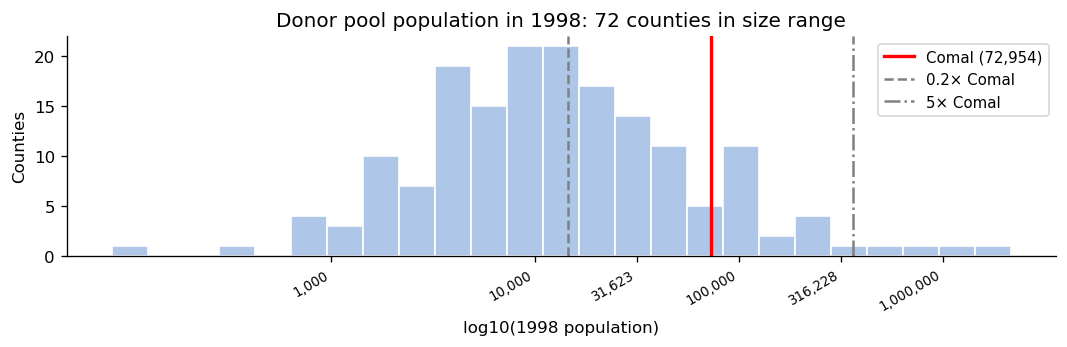

In [3]:
POP_LO = COMAL_POP_1998 * 0.2   # ~14,600
POP_HI = COMAL_POP_1998 * 5.0   # ~365,000

pop98 = donors[donors['year'] == 1998][['fips', 'population']].dropna()
too_small = pop98[pop98['population'] < POP_LO]['fips'].tolist()
too_large = pop98[pop98['population'] > POP_HI]['fips'].tolist()
exclude_size = too_small + too_large

print(f'Comal County 1998 population: {COMAL_POP_1998:,.0f}')
print(f'Size filter range: {POP_LO:,.0f} – {POP_HI:,.0f}')
print(f'Too small (<{POP_LO:,.0f}): {len(too_small)} counties')
print(f'Too large (>{POP_HI:,.0f}): {len(too_large)} counties')
print(f'Total excluded by size filter: {len(exclude_size)}')

# Plot population distribution
fig, ax = plt.subplots(figsize=(9, 3))
in_range = pop98[(pop98['population'] >= POP_LO) & (pop98['population'] <= POP_HI)]
ax.hist(np.log10(pop98['population'] + 1), bins=25, color='#aec7e8', edgecolor='white')
ax.axvline(np.log10(COMAL_POP_1998), color='red', linewidth=2, label=f'Comal ({COMAL_POP_1998:,})')
ax.axvline(np.log10(POP_LO), color='gray', linewidth=1.5, linestyle='--', label=f'0.2× Comal')
ax.axvline(np.log10(POP_HI), color='gray', linewidth=1.5, linestyle='-.', label=f'5× Comal')
ax.set_xlabel('log10(1998 population)')
ax.set_ylabel('Counties')
ax.set_title(f'Donor pool population in 1998: {len(in_range)} counties in size range')
ax.legend(fontsize=9)
# Add actual tick labels
ticks = [3, 4, 4.5, 5, 5.5, 6]
ax.set_xticks(ticks)
ax.set_xticklabels([f'{10**t:,.0f}' for t in ticks], rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../data/processed/panels/donor_size_filter.png', dpi=150, bbox_inches='tight')
plt.show()

## Screen 3: Structural Outliers

Counties with extreme pre-treatment unemployment rates (avg > 12% in 1990–1998) are structurally incomparable to Comal County (whose avg was ~4%).  
These are typically agriculture/maquiladora border counties with persistent high unemployment.

Comal avg unemployment 1990–1998: 4.3%
Structural outlier threshold: >12.0%
Counties excluded: 7
fips
48427    31.788889
48377    30.588889
48323    30.300000
48507    23.900000
48127    16.811111
48505    13.322222
48465    12.322222
Name: laus_unemployment_rate, dtype: float64


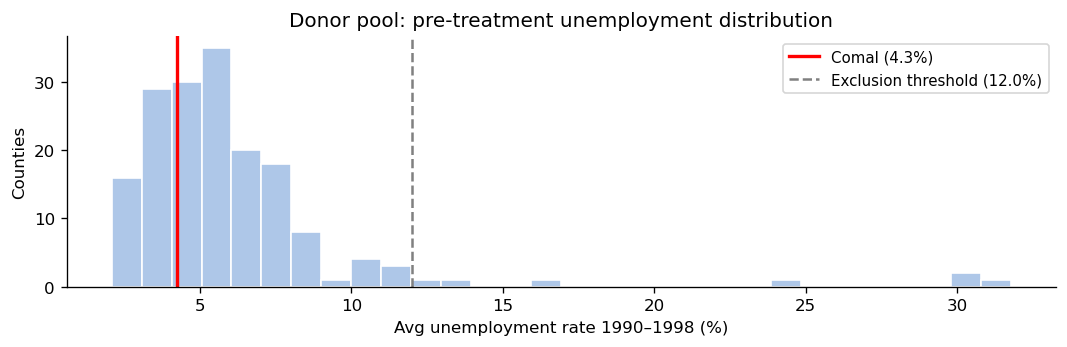

In [4]:
UNEMP_THRESHOLD = 12.0  # percent

avg_unemp = pre.groupby('fips')['laus_unemployment_rate'].mean()
exclude_structural = avg_unemp[avg_unemp > UNEMP_THRESHOLD].index.tolist()

comal_avg_unemp = comal[(comal['year'] >= PRE_START) & (comal['year'] <= PRE_END)]['laus_unemployment_rate'].mean()

print(f'Comal avg unemployment 1990–1998: {comal_avg_unemp:.1f}%')
print(f'Structural outlier threshold: >{UNEMP_THRESHOLD}%')
print(f'Counties excluded: {len(exclude_structural)}')
print(avg_unemp[avg_unemp > UNEMP_THRESHOLD].sort_values(ascending=False))

# Distribution plot
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(avg_unemp, bins=30, color='#aec7e8', edgecolor='white')
ax.axvline(comal_avg_unemp, color='red', linewidth=2, label=f'Comal ({comal_avg_unemp:.1f}%)')
ax.axvline(UNEMP_THRESHOLD, color='gray', linewidth=1.5, linestyle='--',
           label=f'Exclusion threshold ({UNEMP_THRESHOLD}%)')
ax.set_xlabel('Avg unemployment rate 1990–1998 (%)')
ax.set_ylabel('Counties')
ax.set_title('Donor pool: pre-treatment unemployment distribution')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Screened Donor Pool: Summary

In [5]:
# Combine all exclusion lists
all_excluded = set(exclude_coverage) | set(exclude_size) | set(exclude_structural)
all_fips = donors['fips'].unique().tolist()
screened_fips = [f for f in all_fips if f not in all_excluded]

print(f'Starting pool:             {len(all_fips):>4d} counties')
print(f'Excluded by coverage:      {len(exclude_coverage):>4d}')
print(f'Excluded by size (pop):    {len(set(exclude_size)):>4d}')
print(f'Excluded by unemployment:  {len(exclude_structural):>4d}')
print(f'Total excluded:            {len(all_excluded):>4d}')
print(f'────────────────────────────────')
print(f'Final screened pool:       {len(screened_fips):>4d} counties')

# Build a summary table
pop98_dict = pop98.set_index('fips')['population'].to_dict()
unemp_dict = avg_unemp.to_dict()
inc_dict = pre.groupby('fips')['per_capita_income_real'].mean().to_dict()

screened_summary = pd.DataFrame({
    'fips': screened_fips,
    'pop_1998':        [pop98_dict.get(f, np.nan) for f in screened_fips],
    'avg_unemp_pre':   [unemp_dict.get(f, np.nan) for f in screened_fips],
    'avg_pci_pre':     [inc_dict.get(f, np.nan)   for f in screened_fips],
}).sort_values('pop_1998', ascending=False)

print(f'\nScreened pool statistics (1990–1998 pre-treatment):')
print(f'  Population  : {screened_summary["pop_1998"].min():>8,.0f} – {screened_summary["pop_1998"].max():>8,.0f}')
print(f'  Avg unemp   : {screened_summary["avg_unemp_pre"].min():>8.1f}% – {screened_summary["avg_unemp_pre"].max():>8.1f}%')
print(f'  Avg PCI real: {screened_summary["avg_pci_pre"].min():>8,.0f} – {screened_summary["avg_pci_pre"].max():>8,.0f}')
screened_summary.head(10)

Starting pool:              171 counties
Excluded by coverage:         2
Excluded by size (pop):      99
Excluded by unemployment:     7
Total excluded:             102
────────────────────────────────
Final screened pool:         69 counties

Screened pool statistics (1990–1998 pre-treatment):
  Population  :   14,657 –  239,602
  Avg unemp   :      2.6% –     10.2%
  Avg PCI real:   21,206 –   46,852


,fips,pop_1998,avg_unemp_pre,avg_pci_pre
39,48303,239602.0,4.555556,33784.086266
1,48027,233367.0,5.800000,33764.871680
65,48491,220434.0,2.622222,36924.186007
40,48309,209800.0,5.511111,31482.181178
4,48041,147555.0,2.966667,27671.203071
63,48485,132120.0,5.655556,34471.501629
57,48441,125427.0,5.122222,33493.712934
11,48135,123544.0,7.511111,29347.583231
31,48251,118815.0,5.100000,31570.153716
41,48329,118321.0,5.288889,43715.918213


In [6]:
# Annotate excluded counties with reason
donor_meta = []
for f in all_fips:
    reasons = []
    if f in exclude_coverage:   reasons.append('coverage')
    if f in exclude_size:        reasons.append('size')
    if f in exclude_structural:  reasons.append('high_unemployment')
    donor_meta.append({
        'fips':          f,
        'pop_1998':      pop98_dict.get(f, np.nan),
        'avg_unemp_pre': unemp_dict.get(f, np.nan),
        'avg_pci_real':  inc_dict.get(f, np.nan),
        'screened_in':   f not in all_excluded,
        'excluded_by':   ', '.join(reasons) if reasons else '',
    })

meta_df = pd.DataFrame(donor_meta)
meta_df.to_csv('../data/processed/panels/donor_pool_screened.csv', index=False)
print(f'Saved: data/processed/panels/donor_pool_screened.csv ({len(meta_df)} rows)')
meta_df[meta_df['screened_in']].shape

Saved: data/processed/panels/donor_pool_screened.csv (171 rows)


(69, 6)

## Pre-Treatment Trend Inspection: Screened Donor Pool

Verify that the screened pool has plausible pre-treatment trajectories relative to Comal County.

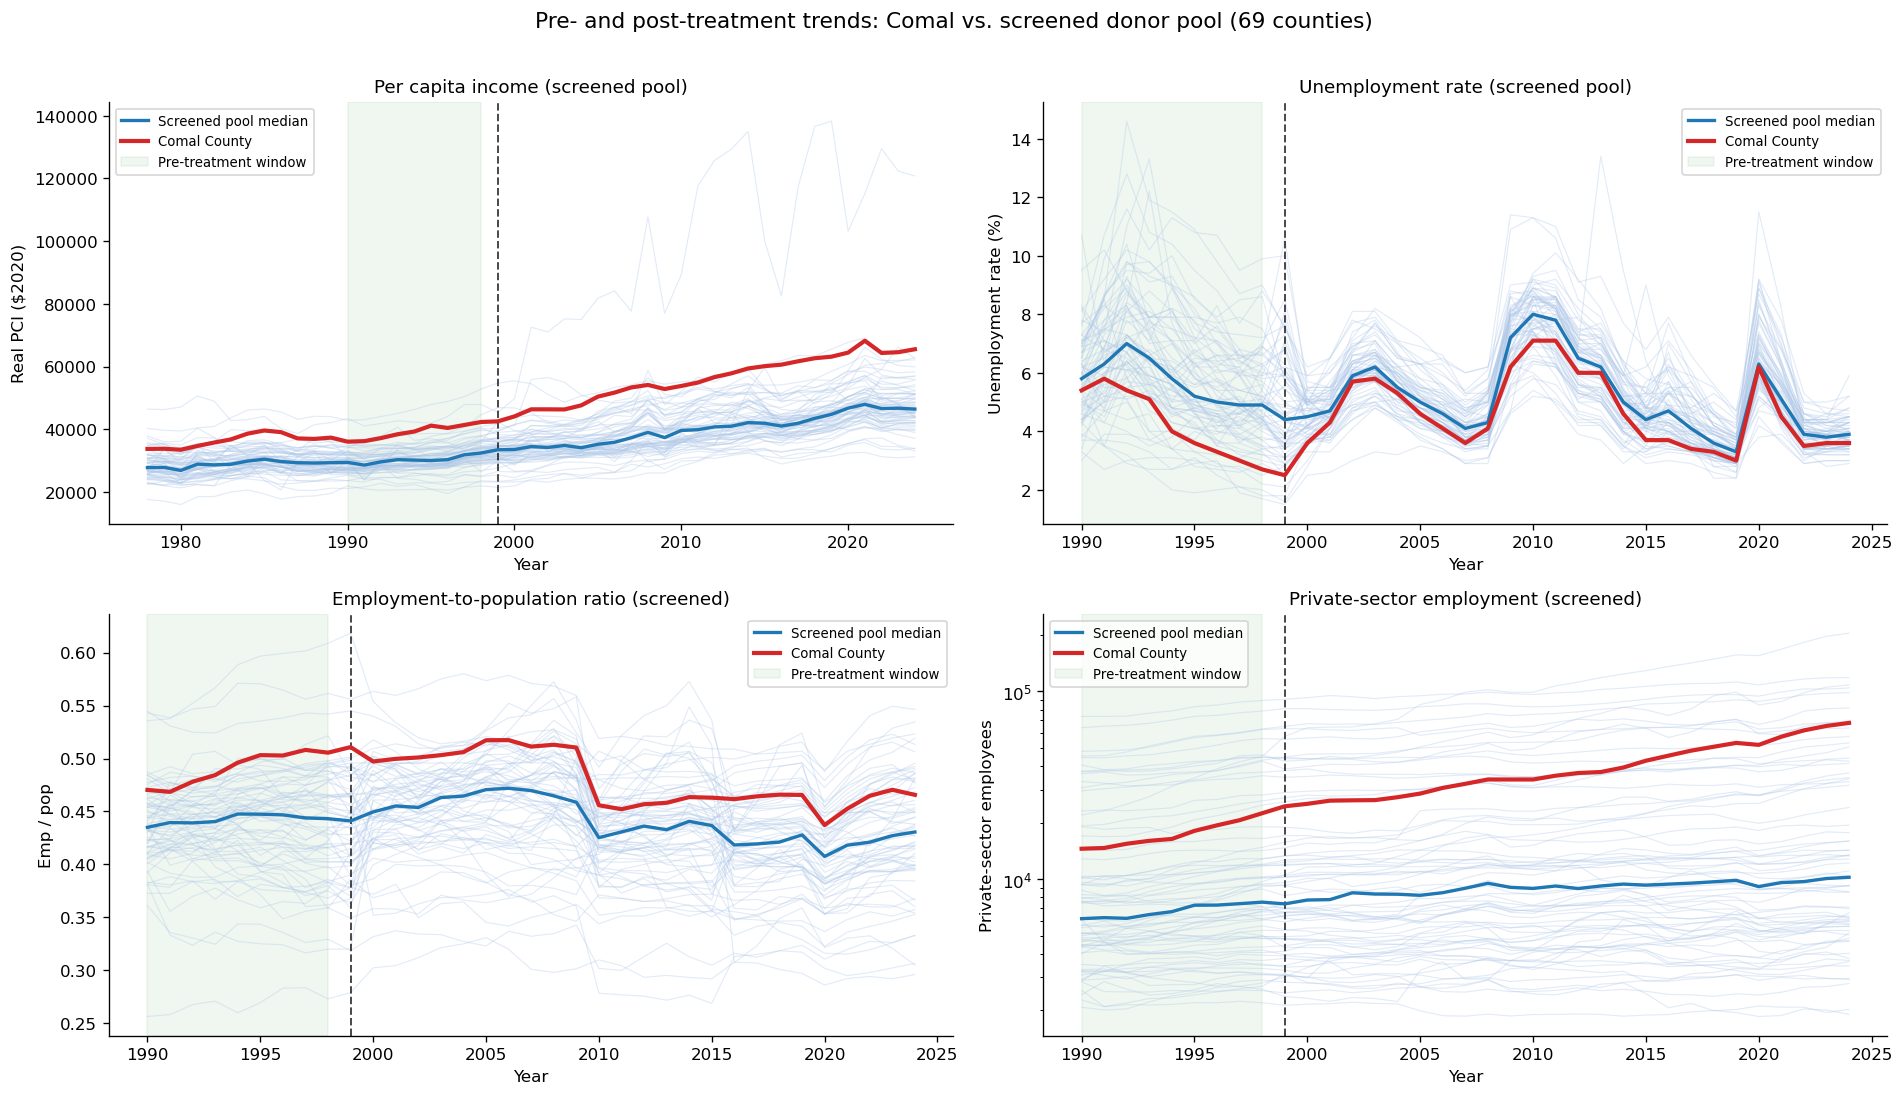

In [7]:
screened_panel = panel[panel['fips'].isin(screened_fips)]

def plot_screened_trends(outcome, ylabel, title, log_scale=False, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    # Screened donor pool (individual)
    for fips, grp in screened_panel.groupby('fips'):
        ax.plot(grp['year'], grp[outcome], color='#aec7e8', alpha=0.35, linewidth=0.7)
    # Donor median
    med = screened_panel.groupby('year')[outcome].median()
    ax.plot(med.index, med.values, color='#1f77b4', linewidth=2, label='Screened pool median', zorder=3)
    # Comal
    ax.plot(comal['year'], comal[outcome], color='#d62728', linewidth=2.5, label='Comal County', zorder=4)
    # Flood marker
    ax.axvline(1999, color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    # Pre-treatment shading
    ax.axvspan(PRE_START, PRE_END, alpha=0.06, color='green', label='Pre-treatment window')
    if log_scale:
        ax.set_yscale('log')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    return ax

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
plot_screened_trends('per_capita_income_real', 'Real PCI ($2020)',
                     'Per capita income (screened pool)', ax=axes[0,0])
plot_screened_trends('laus_unemployment_rate', 'Unemployment rate (%)',
                     'Unemployment rate (screened pool)', ax=axes[0,1])
plot_screened_trends('emp_pop_ratio', 'Emp / pop',
                     'Employment-to-population ratio (screened)', ax=axes[1,0])
plot_screened_trends('qcew_employment', 'Private-sector employees',
                     'Private-sector employment (screened)', log_scale=True, ax=axes[1,1])

plt.suptitle(f'Pre- and post-treatment trends: Comal vs. screened donor pool ({len(screened_fips)} counties)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/panels/screened_pool_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## Variable Selection for SCM

Choose predictor variables and pre-treatment averages for the SCM optimization.  
Standard practice: use pre-treatment averages of the primary outcome in two sub-periods + structural covariates.

In [8]:
# Pre-treatment covariate summary for Comal
comal_pre = comal[(comal['year'] >= PRE_START) & (comal['year'] <= PRE_END)]

# Two sub-period averages for primary outcome
pci_early = comal[(comal['year'] >= 1990) & (comal['year'] <= 1993)]['per_capita_income_real'].mean()
pci_late  = comal[(comal['year'] >= 1994) & (comal['year'] <= 1998)]['per_capita_income_real'].mean()

print('Recommended SCM predictor set:')
print('─' * 55)
print('OUTCOME VARIABLE')
print(f'  per_capita_income_real (primary outcome, 1978–2022)')
print()
print('PREDICTORS (pre-treatment averages for optimization)')
print(f'  per_capita_income_real (avg 1990–1993): {pci_early:,.0f}')
print(f'  per_capita_income_real (avg 1994–1998): {pci_late:,.0f}')
print(f'  laus_unemployment_rate (avg 1990–1998): {comal_pre["laus_unemployment_rate"].mean():.2f}%')
print(f'  emp_pop_ratio (avg 1990–1998):          {comal_pre["emp_pop_ratio"].mean():.4f}')

# Structural covariates (latest pre-treatment ACS)
acs_vars = ['poverty_rate', 'college_share', 'median_household_income_real']
for v in acs_vars:
    val = comal_pre[v].mean()
    if not np.isnan(val):
        print(f'  {v} (avg 1990–1998):         {val:,.2f}')

print()
print('NOTES')
print('  - ACS covariates are forward/back-filled from 2000/2009;')
print('    pre-1990 values reflect back-filled 2000 Census data.')
print('  - qcew_avg_annual_pay_real can be added as industry wage proxy.')
print('  - bps_units can be added as housing market proxy.')

Recommended SCM predictor set:
───────────────────────────────────────────────────────
OUTCOME VARIABLE
  per_capita_income_real (primary outcome, 1978–2022)

PREDICTORS (pre-treatment averages for optimization)
  per_capita_income_real (avg 1990–1993): 37,008
  per_capita_income_real (avg 1994–1998): 40,947
  laus_unemployment_rate (avg 1990–1998): 4.26%
  emp_pop_ratio (avg 1990–1998):          0.4908
  poverty_rate (avg 1990–1998):         0.99
  college_share (avg 1990–1998):         0.00
  median_household_income_real (avg 1990–1998):         81,068.22

NOTES
  - ACS covariates are forward/back-filled from 2000/2009;
    pre-1990 values reflect back-filled 2000 Census data.
  - qcew_avg_annual_pay_real can be added as industry wage proxy.
  - bps_units can be added as housing market proxy.


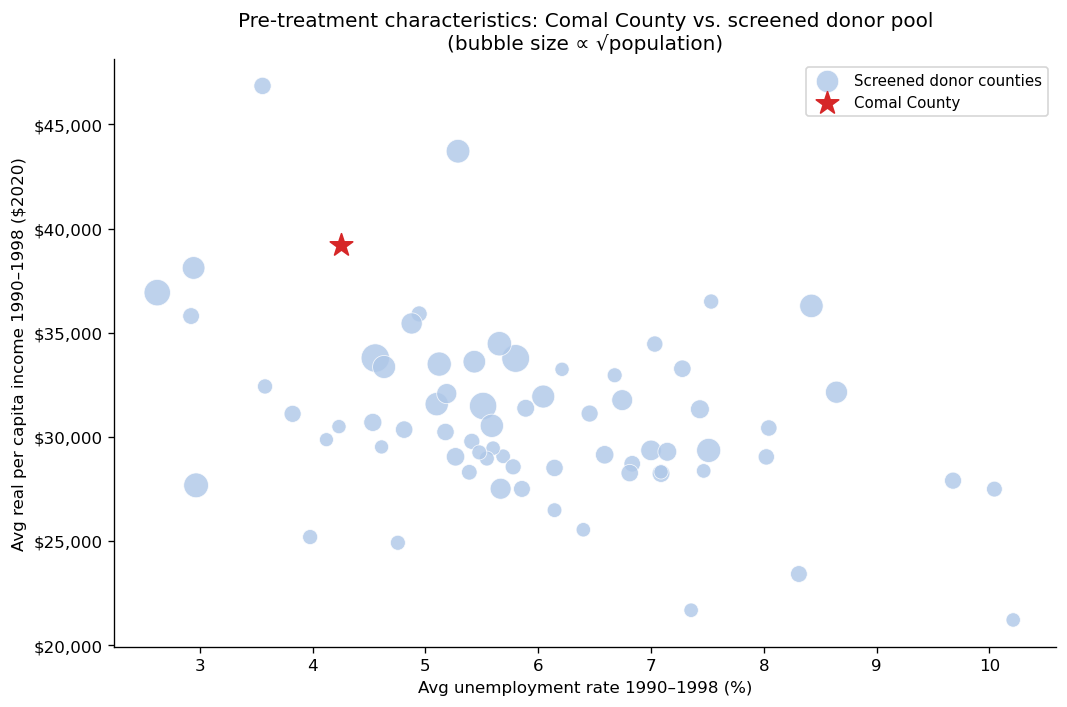

In [9]:
# Scatter: pre-treatment PCI vs. unemployment for screened pool
# Highlight Comal and contextualise the donor pool
fig, ax = plt.subplots(figsize=(9, 6))

screened_pre = screened_panel[(screened_panel['year'] >= PRE_START) & (screened_panel['year'] <= PRE_END)]
donor_agg = screened_pre.groupby('fips').agg(
    pci=('per_capita_income_real', 'mean'),
    unemp=('laus_unemployment_rate', 'mean'),
    pop=('population', 'mean'),
).reset_index()

comal_agg = comal_pre[['per_capita_income_real', 'laus_unemployment_rate', 'population']].mean()

sc = ax.scatter(
    donor_agg['unemp'], donor_agg['pci'],
    s=np.sqrt(donor_agg['pop']) * 0.6,
    c='#aec7e8', edgecolors='white', linewidths=0.5, alpha=0.8, label='Screened donor counties'
)
ax.scatter(
    comal_agg['laus_unemployment_rate'], comal_agg['per_capita_income_real'],
    s=200, color='#d62728', zorder=5, label='Comal County', marker='*'
)
ax.set_xlabel('Avg unemployment rate 1990–1998 (%)')
ax.set_ylabel('Avg real per capita income 1990–1998 ($2020)')
ax.set_title('Pre-treatment characteristics: Comal County vs. screened donor pool\n(bubble size ∝ √population)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../data/processed/panels/donor_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary & Output for R

In [10]:
print('=' * 60)
print('DONOR SCREENING SUMMARY')
print('=' * 60)
print(f"""
Starting pool       : 171 donor-eligible counties
After coverage filter: {171 - len(exclude_coverage)} counties (removed {len(exclude_coverage)})
After size filter   : {171 - len(set(exclude_size))} counties (removed {len(set(exclude_size))})
After structural    : {len(screened_fips)} counties (removed {len(exclude_structural)} high-unemployment)

Final screened pool : {len(screened_fips)} counties

Recommended R inputs
─────────────────────────────────────────────────────────────
Panel file   : data/processed/panels/scm_panel.csv
Screened FIPS: data/processed/panels/donor_pool_screened.csv
  (filter to screened_in == TRUE, plus TREATED_FIPS == '48091')

Recommended SCM setup
─────────────────────────────────────────────────────────────
Treated unit   : 48091 (Comal County)
Treatment year : 1999
Pre-period     : 1990–1998 (9 years)
Post-period    : 1999–2022 (23 years, until most sources end)
Primary outcome: per_capita_income_real

Predictors
  per_capita_income_real   (avg 1990–1993 AND avg 1994–1998)
  laus_unemployment_rate   (avg 1990–1998)
  emp_pop_ratio            (avg 1990–1998)
  qcew_avg_annual_pay_real (avg 1990–1998, wage proxy)
  poverty_rate             (avg — back-filled from 2000)
  college_share            (avg — back-filled from 2000)
""")

# Export screened FIPS for R
screened_for_r = pd.DataFrame({'fips': screened_fips + [TREATED_FIPS]})
screened_for_r = screened_for_r.drop_duplicates()
screened_for_r.to_csv('../data/processed/panels/scm_fips_list.csv', index=False)
print(f'Saved: data/processed/panels/scm_fips_list.csv ({len(screened_for_r)} rows incl. treated)')

DONOR SCREENING SUMMARY

Starting pool       : 171 donor-eligible counties
After coverage filter: 169 counties (removed 2)
After size filter   : 72 counties (removed 99)
After structural    : 69 counties (removed 7 high-unemployment)

Final screened pool : 69 counties

Recommended R inputs
─────────────────────────────────────────────────────────────
Panel file   : data/processed/panels/scm_panel.csv
Screened FIPS: data/processed/panels/donor_pool_screened.csv
  (filter to screened_in == TRUE, plus TREATED_FIPS == '48091')

Recommended SCM setup
─────────────────────────────────────────────────────────────
Treated unit   : 48091 (Comal County)
Treatment year : 1999
Pre-period     : 1990–1998 (9 years)
Post-period    : 1999–2022 (23 years, until most sources end)
Primary outcome: per_capita_income_real

Predictors
  per_capita_income_real   (avg 1990–1993 AND avg 1994–1998)
  laus_unemployment_rate   (avg 1990–1998)
  emp_pop_ratio            (avg 1990–1998)
  qcew_avg_annual_pay_real (